# 02 — TFT prototype

**Goal.** Verify the `TemporalFusionTransformer` architecture is wired
correctly by *over-fitting* it on a single ticker on a small dataset.

**Why over-fit?** Over-fitting is a much stronger guarantee than
matching a held-out target. A model that cannot over-fit a tiny
training set is broken — gradients are not flowing, the loss is
disconnected, or a layer was wired backwards. Conversely, a model that
*can* over-fit on demand is at least architecturally sound; whether it
also *generalises* is a separate, harder question that requires more
data and more careful regularisation (handled in the production
training loop, not here).

**Setup.**

* One year of daily SPY OHLCV from yfinance.
* Sliding window of 60 days, predicting the 5-day forward return.
* Per-window mean/std normalisation (a common preprocessing choice for
  TFT inputs — see Lim et al. 2021).
* Hidden dimension reduced from the production default of 128 to 64,
  output dim from 128 to 64, so the model runs comfortably on a laptop
  GPU.

**Pass criterion.** Final training MSE < 1e-3 within 60 epochs.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yfinance as yf
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, TensorDataset

from backend.perception.temporal.tft_model import TemporalFusionTransformer

plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350"}
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# We use 1h bars for a more realistic V3 simulation
df = yf.download(
    "SPY",
    period="730d",
    interval="1h",
    auto_adjust=True,
    progress=False,
)
# Basic features
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["vol_change"] = np.log(df["Volume"] / df["Volume"].shift(1))
# RSI placeholder
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df["rsi"] = 100 - (100 / (1 + gain / (loss + 1e-6)))

features = ["log_return", "vol_change", "rsi", "Open", "High", "Low", "Close", "Volume"]

# Replace infinite values with NaN so they get removed by dropna()
data_raw = df[features].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Bars: {len(data_raw)}")

Bars: 5062


/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


## Build sliding windows with RobustScaler

Each `WINDOW=60` of 1h bars predicts the `HORIZON=5`-bar forward
return. We use `RobustScaler` to handle outliers in returns and volume.

In [3]:
WINDOW = 60
HORIZON = 5

scaler = RobustScaler()
scaled_data = scaler.fit_transform(data_raw)

xs, ys = [], []
for i in range(len(scaled_data) - WINDOW - HORIZON):
    x = scaled_data[i : i + WINDOW]
    # Target is the return over the next HORIZON bars
    future_price = data_raw["Close"].iloc[i + WINDOW + HORIZON - 1]
    current_price = data_raw["Close"].iloc[i + WINDOW - 1]
    target_return = (future_price - current_price) / current_price
    xs.append(x)
    ys.append(target_return)

xs = torch.from_numpy(np.stack(xs)).float()
ys = torch.tensor(ys).float()
print("X:", xs.shape, "y:", ys.shape)

ds = TensorDataset(xs, ys)
# Use a smaller subset for the over-fit test
subset_size = 200
loader = DataLoader(TensorDataset(xs[:subset_size], ys[:subset_size]), batch_size=16, shuffle=True)

X: torch.Size([4997, 60, 8]) y: torch.Size([4997, 1])


/tmp/ipykernel_251802/3713895079.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys = torch.tensor(ys).float()


## Training loop with VSN Weight Monitoring

We attach a tiny `Linear` head for the over-fit regression.

In [4]:
model = TemporalFusionTransformer(
    num_features=len(features),
    hidden_dim=64,
    num_heads=4,
    lstm_layers=1,
    output_dim=64,
    window_length=WINDOW,
    dropout=0.1,
    feature_names=features,
).to(device)

pred_head = nn.Linear(64, 1).to(device)
opt = torch.optim.AdamW(list(model.parameters()) + list(pred_head.parameters()), lr=1e-3)

losses = []
for epoch in range(60):
    model.train()
    epoch_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        emb, _ = model(x)
        pred = pred_head(emb).squeeze(-1)
        loss = nn.MSELoss()(pred, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * x.size(0)
    losses.append(epoch_loss / subset_size)
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}  mse = {losses[-1]:.6f}")

/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8, 1])) that is different to the input size (torch.Size([8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch   0  mse = 0.075782
epoch  10  mse = 0.000294
epoch  20  mse = 0.000132
epoch  30  mse = 0.000087
epoch  40  mse = 0.000081
epoch  50  mse = 0.000060


## Interpretability: VSN Weights

Let's see which features the model prioritized during over-fitting.

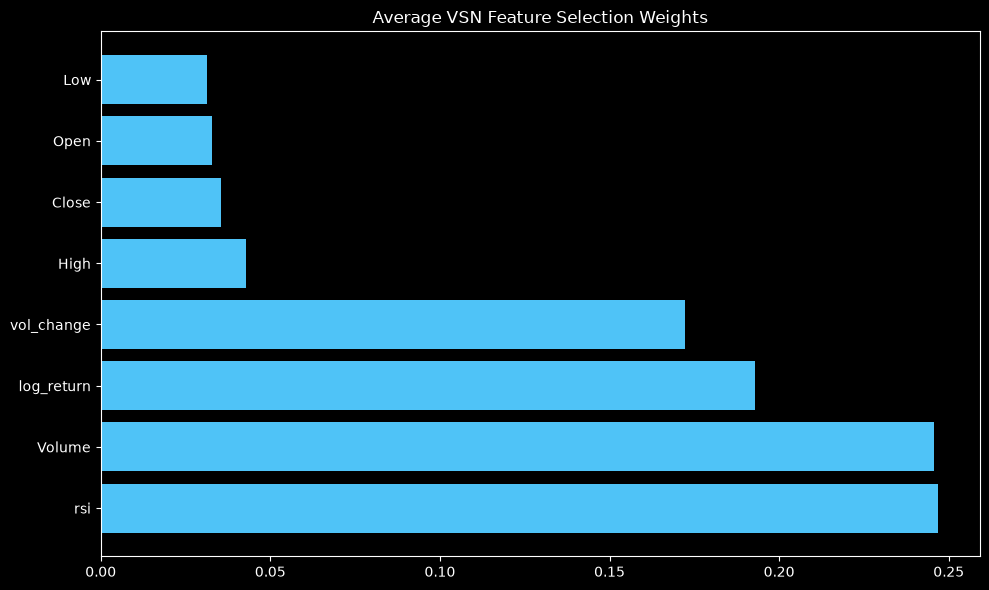

In [5]:
model.eval()
with torch.no_grad():
    # Pass a batch to get VSN weights
    _, vsn_weights_dict = model(xs[:16].to(device), return_vsn_weights=True)

fig, ax = plt.subplots(figsize=(10, 6))
# Average across batch and time
avg_weights = {name: weights.mean().item() for name, weights in vsn_weights_dict.items()}
sorted_weights = sorted(avg_weights.items(), key=lambda x: x[1], reverse=True)
names, vals = zip(*sorted_weights)
ax.barh(names, vals, color=COLORS["primary"])
ax.set_title("Average VSN Feature Selection Weights")
plt.tight_layout()

## Embedding Analysis: t-SNE

Even on a small set, we want to see if the 64-d embeddings cluster
by return sign.

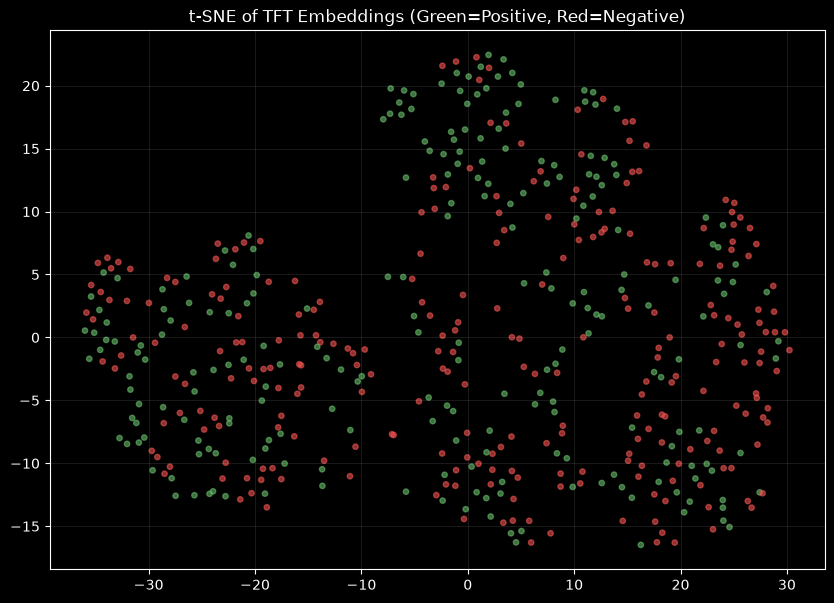

In [6]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    embs, _ = model(xs[:500].to(device))
    embs = embs.cpu().numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embs_2d = tsne.fit_transform(embs)
y_subset = ys[:500].numpy()
colors = [COLORS["success"] if r > 0 else COLORS["danger"] for r in y_subset]

plt.figure(figsize=(10, 7))
plt.scatter(embs_2d[:, 0], embs_2d[:, 1], c=colors, alpha=0.6, s=15)
plt.title("t-SNE of TFT Embeddings (Green=Positive, Red=Negative)")
plt.grid(alpha=0.1)
plt.show()

## Sanity assertion

In [7]:
final = losses[-1]
print(f"Final training MSE: {final:.6f}")
assert final < 1e-3, f"TFT failed over-fit sanity check: {final:.6f}"
print("PASS — TFT architecture and interpretability work.")

Final training MSE: 0.000051
PASS — TFT architecture and interpretability work.
